# **Import Statements**

In [1]:
root = "C:\\Users\\saman\\Documents\\Github\\Magnetic-Levitation\\"

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


from utils.boundary_disk import Cylinder, Disk



%load_ext autoreload
%autoreload 2
plt.style.use(root + "style.mplstyle")


# **Similarity Solution to Rotating Disk with Boundary**

<>:1: SyntaxWarning: invalid escape sequence '\O'
<>:1: SyntaxWarning: invalid escape sequence '\O'
C:\Users\saman\AppData\Local\Temp\ipykernel_23516\2229330522.py:1: SyntaxWarning: invalid escape sequence '\O'
  '''


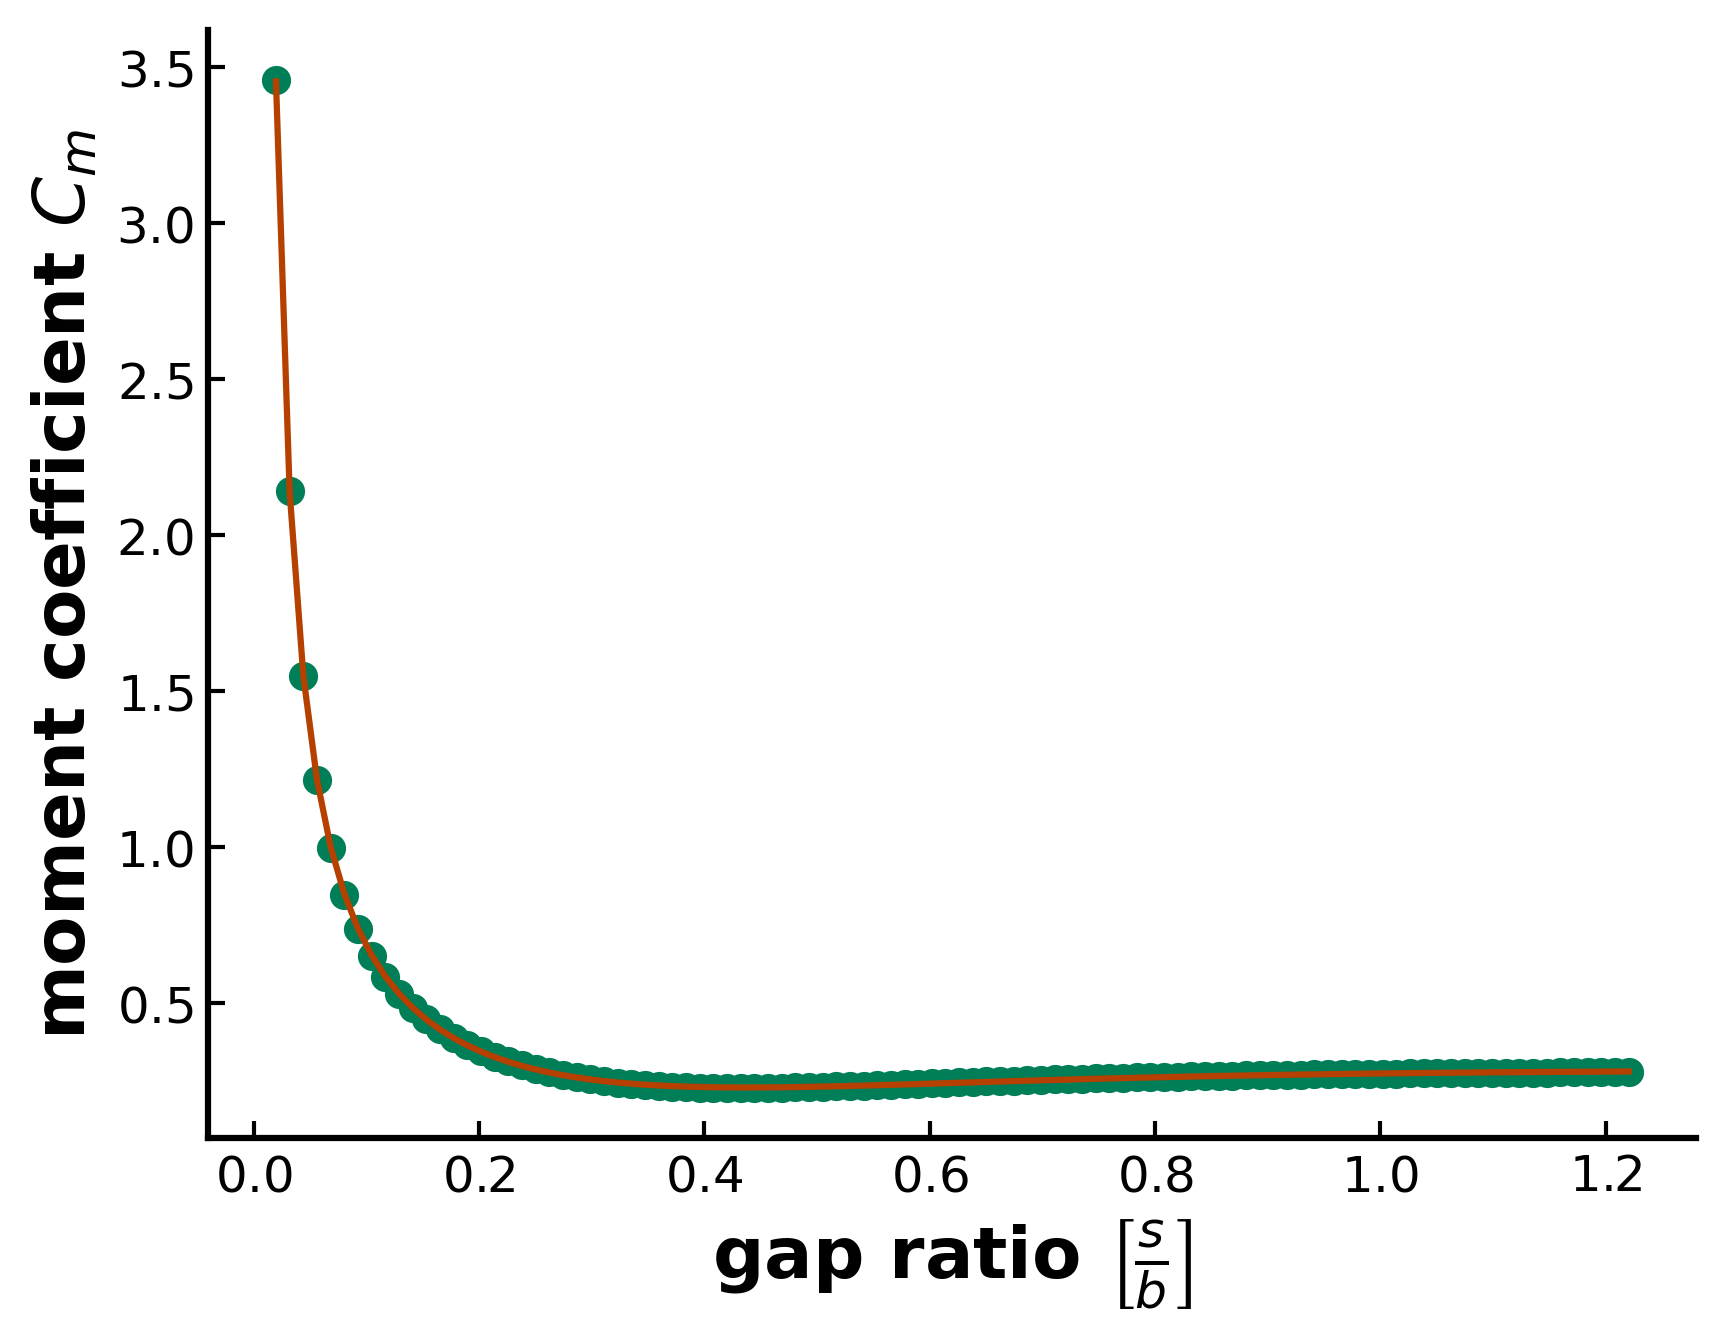

In [ ]:
'''
fig, ax = plt.subplots(1, 2, figsize = (6.4*2, 4.8))
for i in range(5): 
    
    cylinder = Cylinder( 
                b = 0.00254,  # radius in meters
                rho = 7500, # cylinder density in kg/m^3
                Omega = 1000 + 2000*i, # angular velocity in rpm 
                rho_f = 1.226, # density of the fluid in kg/m^3
                mu = 1.795e-5, # viscosity of the fluid in pascal seconds
                elle = 0.0105, # total gap distance in meters
                L = 0.003175 # length of the cylinder in meters
            )
    s_sound, C_m, fit, popt = cylinder.disk_moment_fit(50e-6, 0.0031)

    R_es = cylinder.rho_f *cylinder.Omega*s_sound**2/cylinder.mu
    idx = np.argmin(np.abs(R_es - 30))
    s_crit = s_sound[idx]

    ax[0].plot(s_sound/cylinder.b, C_m/np.max(C_m), label = r"$\Omega$: " + f"{cylinder.Omega *60/(2*np.pi):.0f} rpm")
    ax[1].plot(s_sound/cylinder.b, C_m, label = r"$\Omega$: " + f"{cylinder.Omega *60/(2*np.pi):.0f} rpm")


ax[0].set_ylabel(r"norm moment coeff $\frac{C_m}{C_0}$", weight = 'heavy', fontsize = "xx-large")
ax[1].set_ylabel(r"moment coeff $C_m$", weight = 'heavy', fontsize = "xx-large")

fig.supxlabel(r"gap ratio $\left[\frac{s}{b} \right]$", weight = 'heavy', fontsize = "xx-large")
fig.tight_layout()
plt.legend()
plt.show()
'''
######################################################################################################################################

cylinder = Cylinder( 
            b = 0.00254,  # radius in meters
            rho = 7500, # cylinder density in kg/m^3
            Omega = 1000, # angular velocity in rpm 
            rho_f = 1.226, # density of the fluid in kg/m^3
            mu = 1.795e-5, # viscosity of the fluid in pascal seconds
            elle = 0.0105, # total gap distance in meters
            L = 0.003175 # length of the cylinder in meters
        )
s_sound, M_phi, fit, popt = cylinder.disk_moment_fit(50e-6, 0.0031)

plt.plot(s_sound/cylinder.b, M_phi, linestyle = '', marker = 'o')
plt.plot(s_sound/cylinder.b, fit, label = "fit")#, linestyle = '', marker = '.')
plt.ylabel(r"moment coefficient $C_m$", weight = 'heavy', fontsize = "xx-large")
plt.xlabel(r"gap ratio $\left[\frac{s}{b} \right]$", weight = 'heavy', fontsize = "xx-large")
plt.show()

# **Normalized Dissipation v. Normalized Gap Distance**

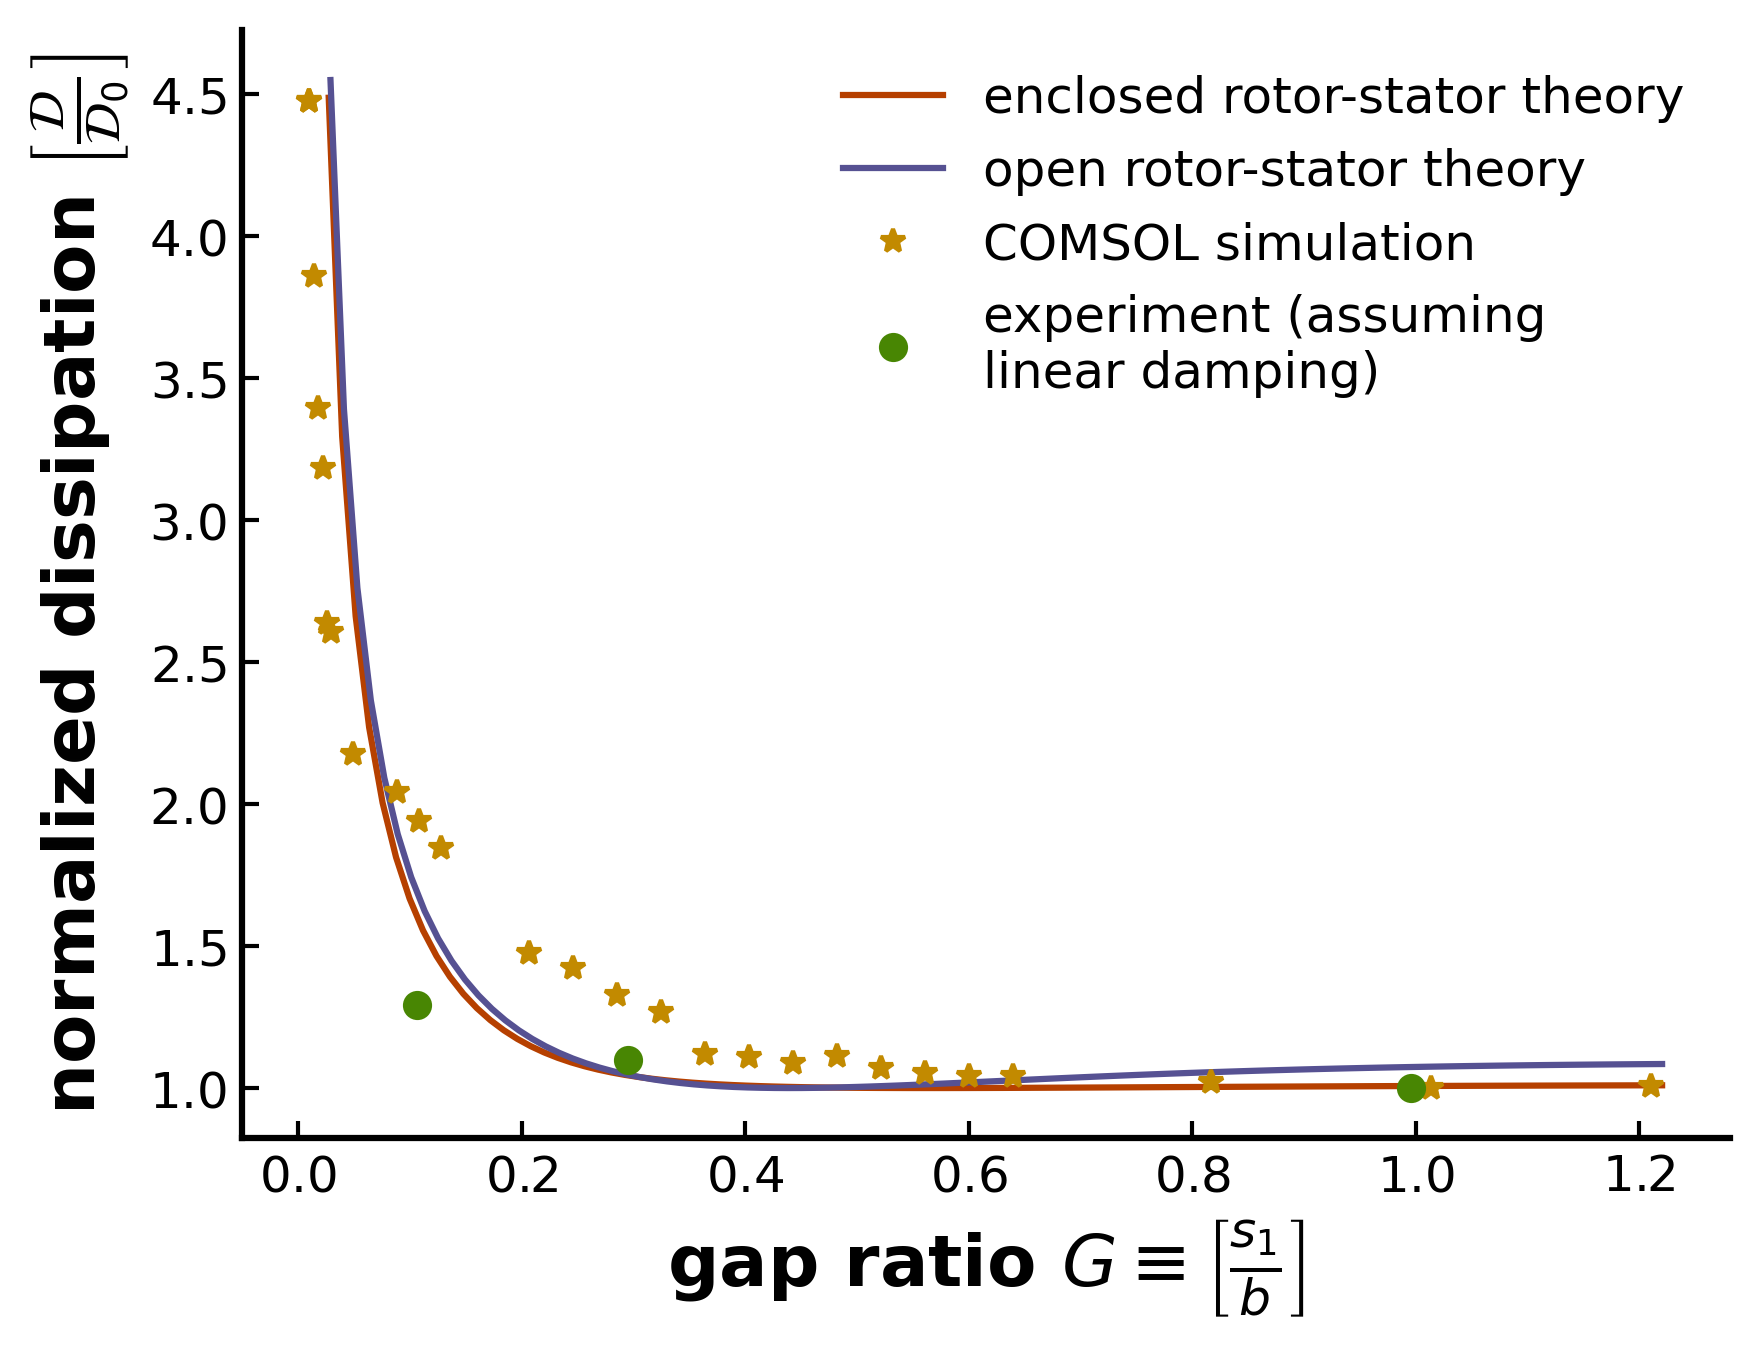

In [24]:
cylinder = Cylinder( 
            b = 0.00254,  # radius in meters
            rho = 7500, # cylinder density in kg/m^3
            Omega = 1000, # angular velocity in rpm 
            rho_f = 1.226, # density of the fluid in kg/m^3
            mu = 1.795e-5, # viscosity of the fluid in pascal seconds
            elle = 0.0105, # total gap distance in meters
            L = 0.003175 # length of the cylinder in meters
        )

gap_exp = np.asarray([0.00027, 0.00075, 0.00253]) #in meters
tau_exp = np.asarray([85, 100, 110]) #in seconds
dissipation_exp = cylinder.I *cylinder.Omega**2/(tau_exp*2*np.pi*cylinder.b*(cylinder.L + cylinder.b))

#Enclosed Rotor-Stator Fit
s_array_ers, dissipation_ers, G_crit_ers = cylinder.enclosed_rotor_stator(
    start = 69e-6, #in meters
    stop = 0.0031 # in meters
)

#Open Rotor-Stator Fit
s_array_ors, dissipation_ors = cylinder.open_rotor_stator(
    start = 73e-6, #in meters
    stop = 0.0031 # in meters
)

#COMSOL Simulation
gap_COMSOL = 2.075  + np.asarray([-2.05, -1.95, -1.85, -1.75, -1.55, -1.45, -1.35, -1.25, -1.15, -1.05, -0.9499999999999997, -0.8499999999999996, -0.7499999999999998,
                                    -0.6499999999999997, -0.5499999999999998, -0.4499999999999997, -2.05, -2.04, -2.03, -2.02, -2.01, -2, -1.8, 1, 0.5, 0]) # in mm
gap_COMSOL = gap_COMSOL/1000 #convert from mm to meters
dissipation_COMSOL = np.asarray([7.276218039755276e-08, 3.54147777132402e-08, 3.319989813145014e-08, 2.999256618224352e-08, 2.397974446357202e-08, 
                                    2.315700597492343e-08, 2.161300607312653e-08, 2.059531916586093e-08, 1.818476156508958e-08, 1.805479547545832e-08,
                                    1.770094325751496e-08, 1.810964892360439e-08, 1.738181837805184e-08, 1.713697045790447e-08, 1.696140911262177e-08,
                                    1.69594542751747e-08, 7.276218039755276e-08, 6.27325979686784e-08, 5.517541944117902e-08, 5.178201911733897e-08, 
                                    4.28650162841852e-08, 4.237478948935986e-08, 3.154069141653727e-08, 1.639943102219439e-08, 1.625977604031675e-08, 1.660765723313549e-08]) #in Watts/m^2

'''
Plotting
'''

# Enclosed Rotor-Stator
plt.plot(s_array_ers/cylinder.b, dissipation_ers/np.min(dissipation_ers), label = 'enclosed rotor-stator theory', c = 'C1')

# Open Rotor-Stator
plt.plot(s_array_ors/cylinder.b, dissipation_ors/np.min(dissipation_ors), label = 'open rotor-stator theory', c = 'C2')

# axvlines
#plt.axvline(x = G_crit_ers, c = 'black', linestyle = '--', label = r'$G_\mathrm{crit, enclosed}$')

# COMSOL
plt.plot(gap_COMSOL/cylinder.b, dissipation_COMSOL/np.min(dissipation_COMSOL), linestyle = '', marker = '*', label = 'COMSOL simulation', c = 'C5')

# Experiment
plt.plot(gap_exp/cylinder.b, dissipation_exp/np.min(dissipation_exp), linestyle = '', marker = 'o', c = 'C4', label = 'experiment (assuming\nlinear damping)')


# Labels
plt.xlabel(r"gap ratio $G \equiv \left[\frac{s_1}{b} \right]$", weight = 'heavy', fontsize = "xx-large")
plt.ylabel(r"normalized dissipation $\left[\frac{\mathcal{D}}{\mathcal{D}_0} \right]$", weight = 'heavy', fontsize = "xx-large")
plt.legend(prop={'size': 12})
plt.show()

# **Regime Mapping**

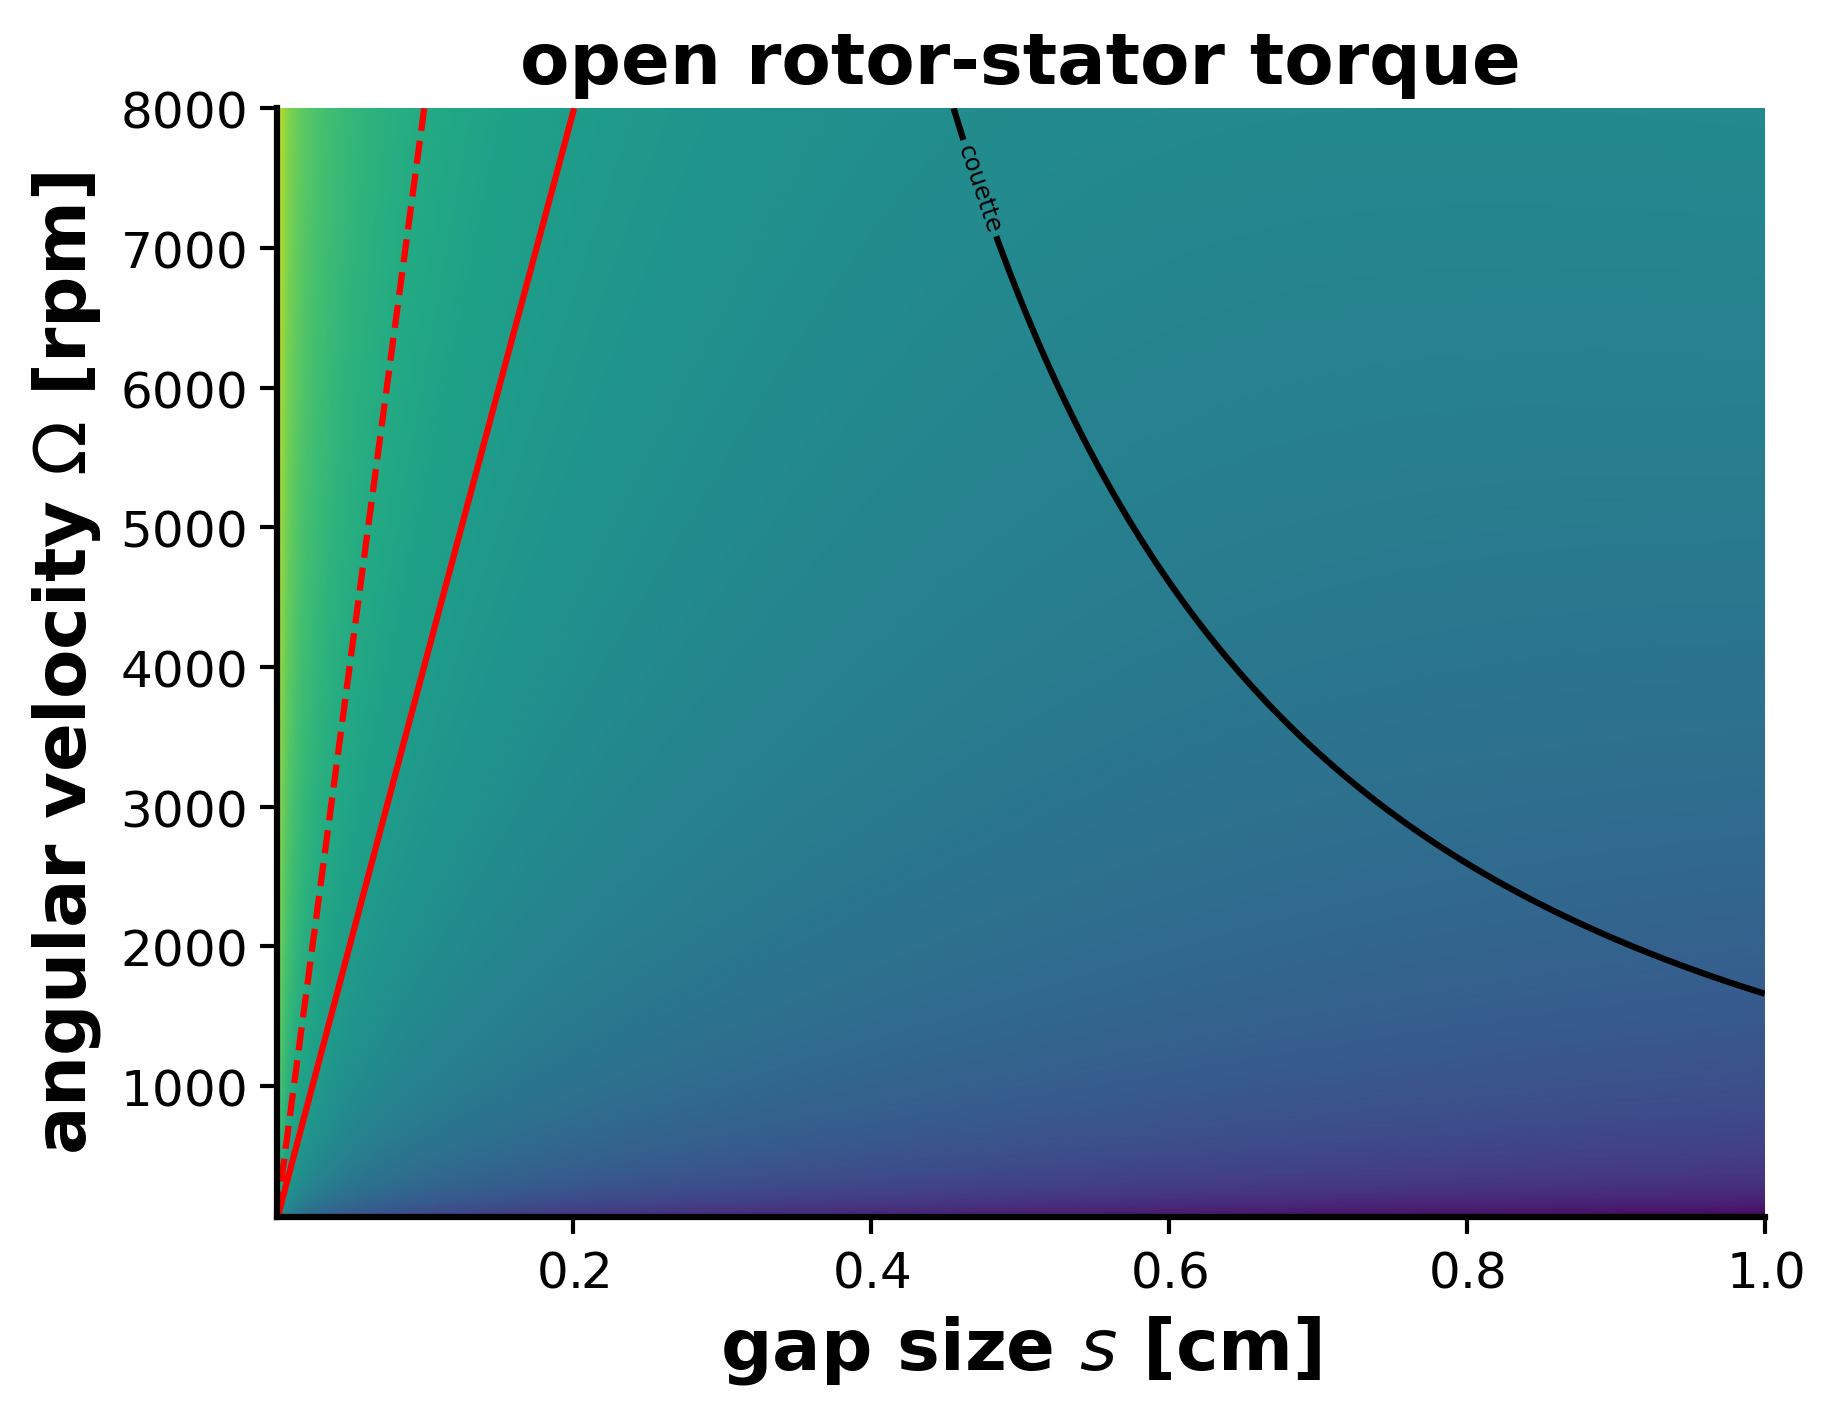

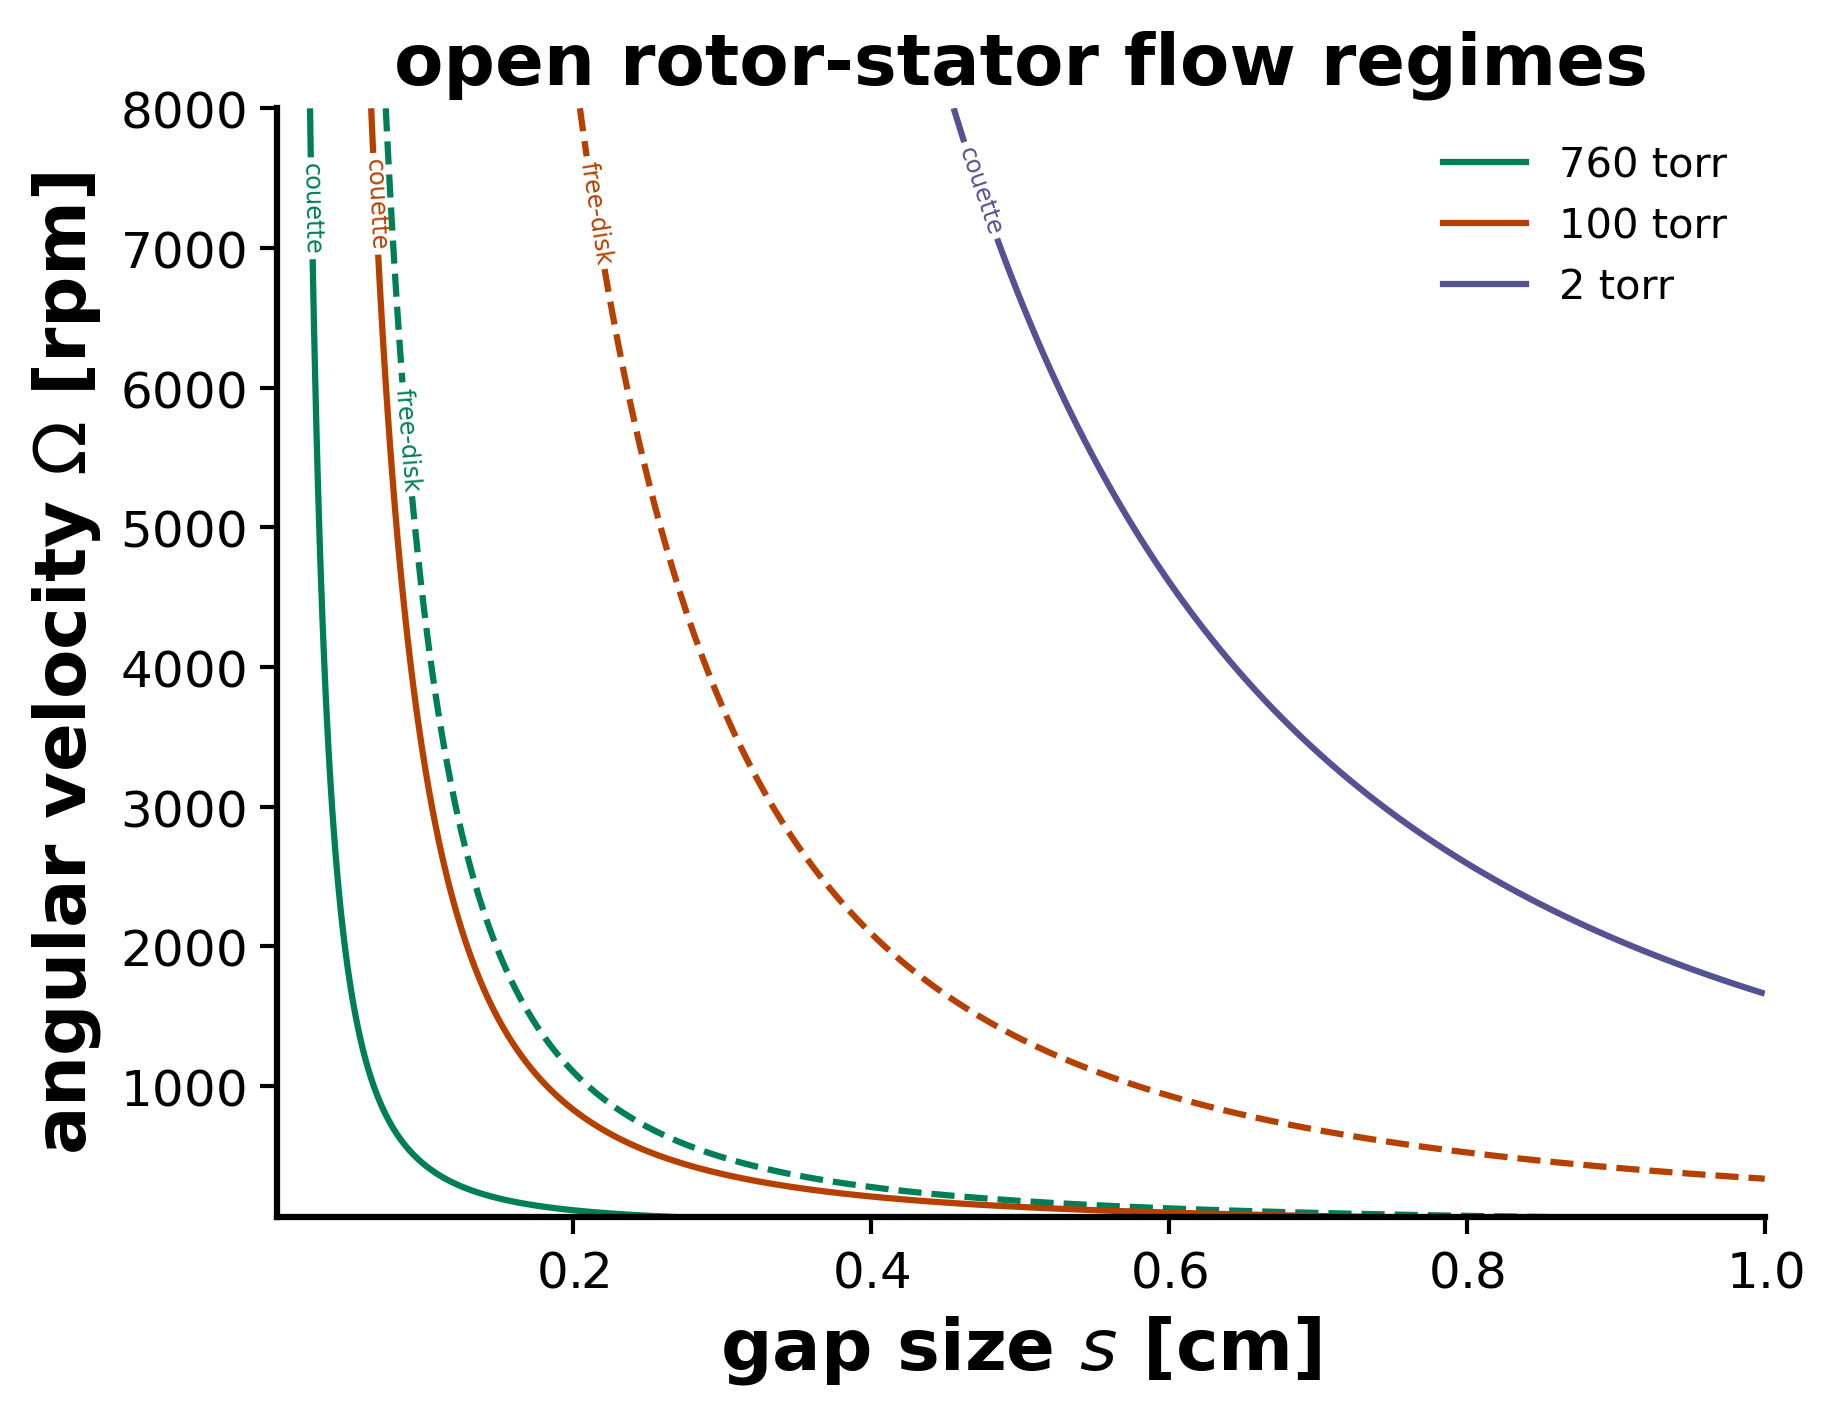

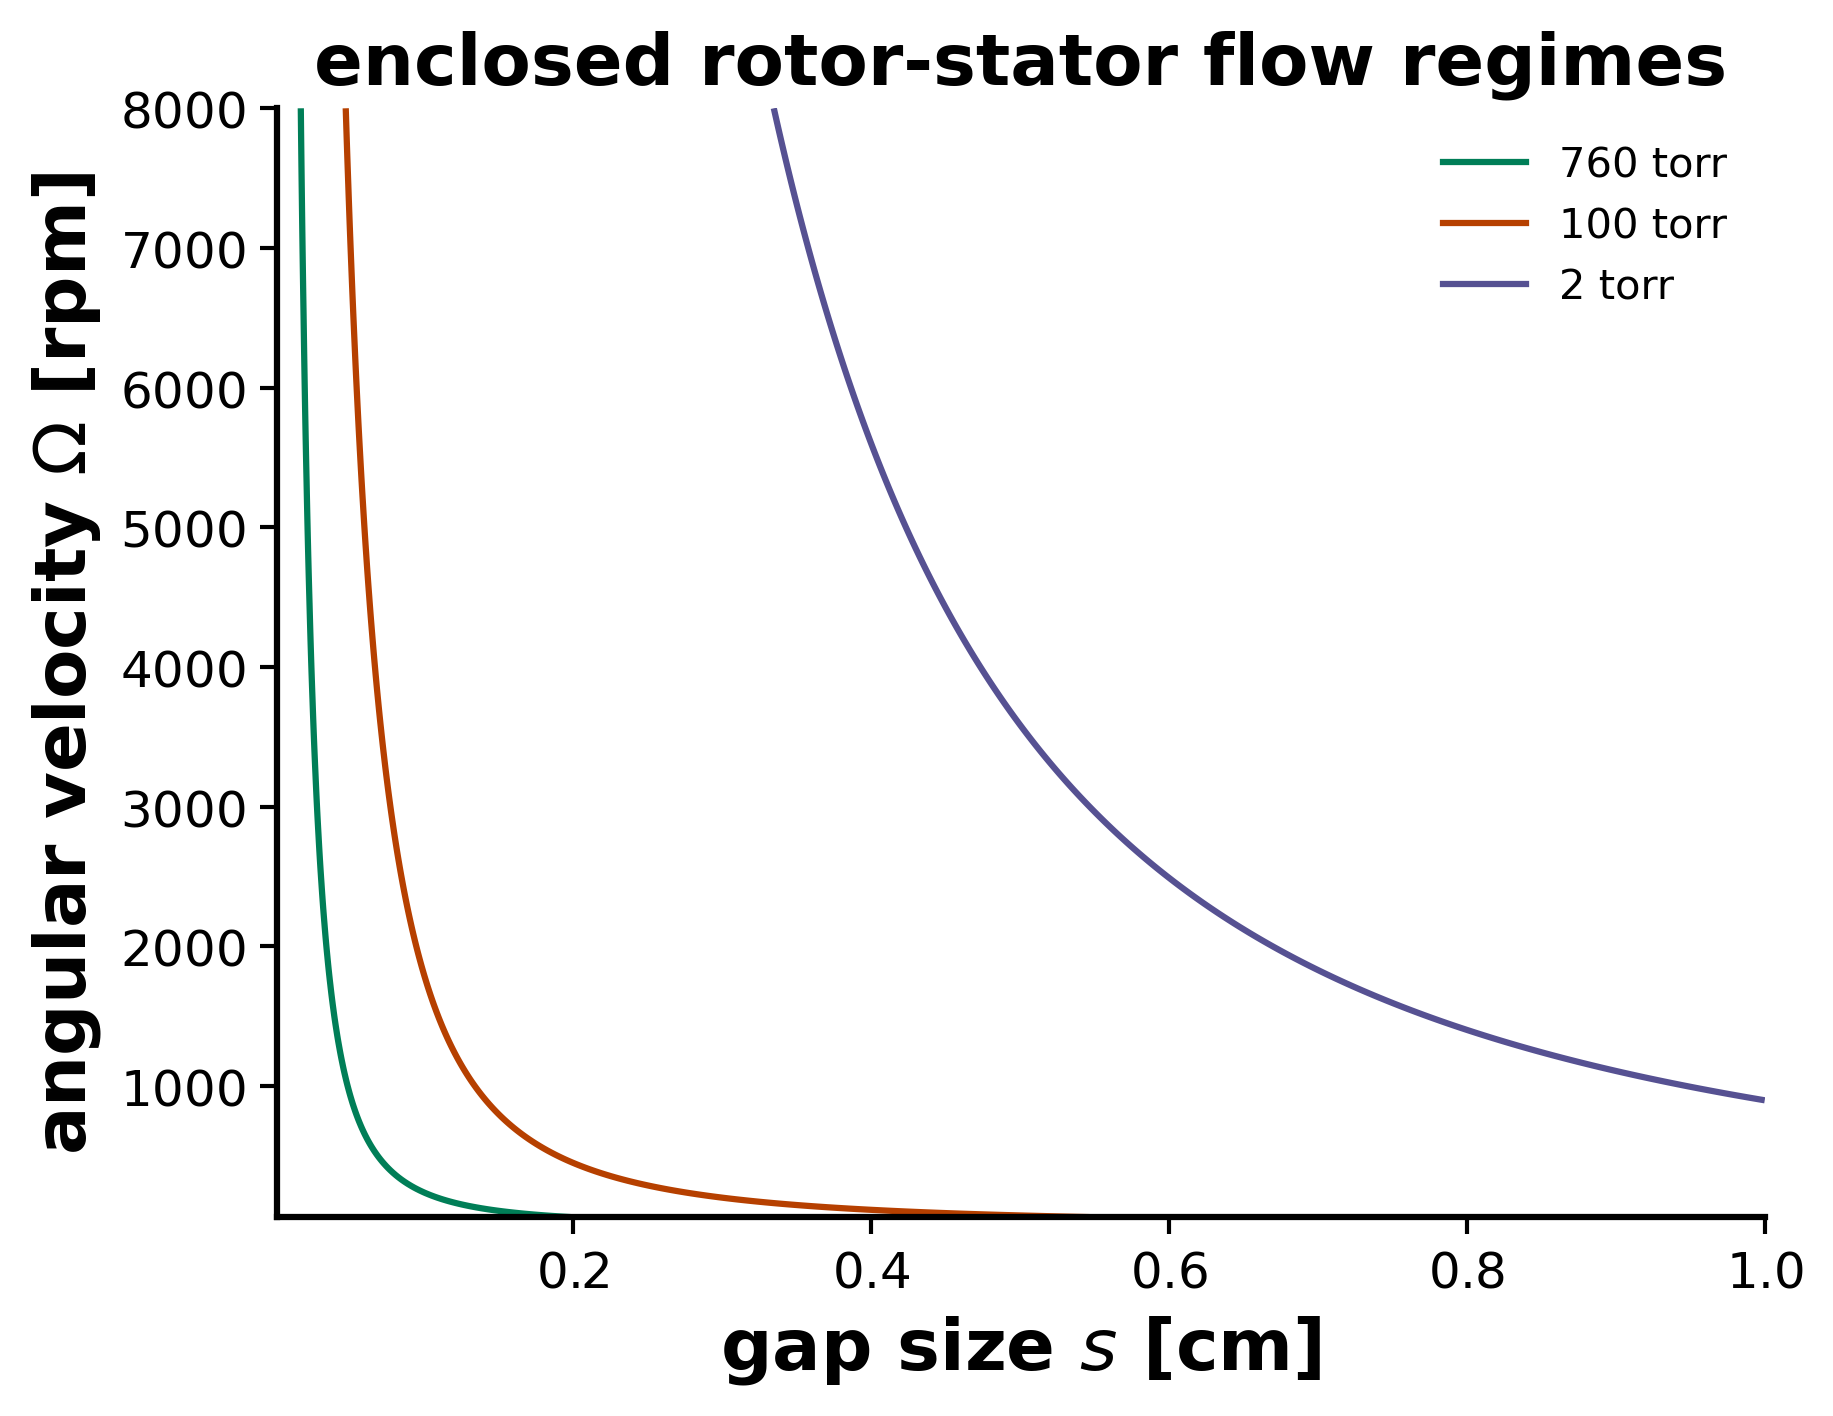

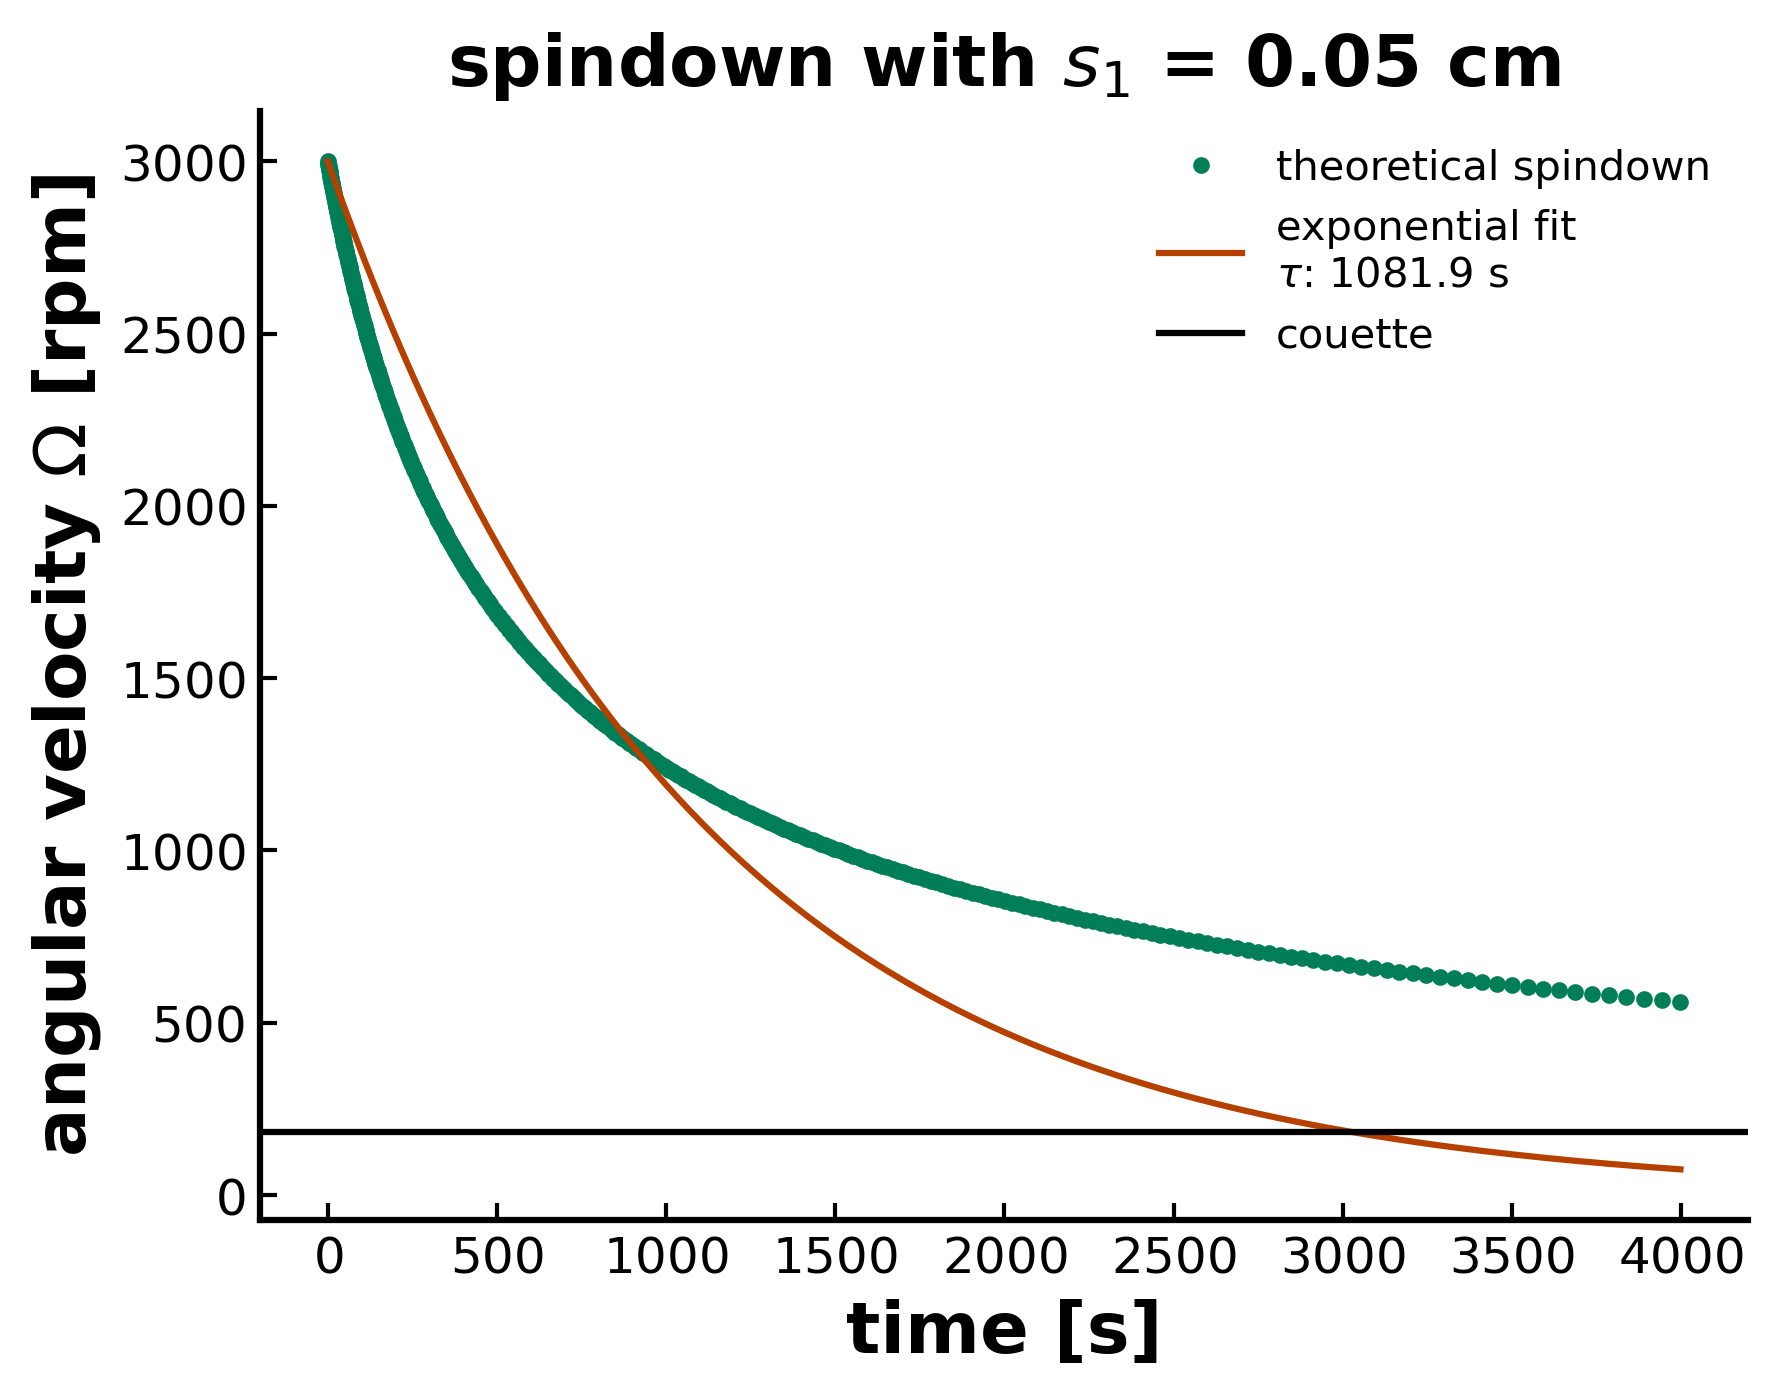

In [6]:
disk = Disk( 
    b = 0.0028, #0.0127,  # radius in meters (radius of 0.0127 is 1 inch diameter)
    rho = 7500, # density of levitated mass
    mu = 1.795e-5, #viscosity in pascal seconds
    elle = 0.0105 #total gap distance in meters
)

ss, ww, R_gap, M_phi = disk.gen_cmapR(s_start = 10e-6, s_stop = 1e-2, omega_start = 60, omega_stop = 8000, rho_f = 4.81e-26*(2*1.0135e5/760)/(1.38e-23*300))

torque_heatmap = plt.pcolormesh(ss*1e2, ww*60/(2*np.pi), np.log(M_phi/np.max(M_phi)), shading='gouraud', cmap= "viridis")
#plt.colorbar()
contour = plt.contour(ss*1e2, ww*60/(2*np.pi), M_phi, levels = [np.max(M_phi)*0.005, np.max(M_phi)*0.01], colors = 'red', linestyles = ['solid', 'dashed'])
contour = plt.contour(ss*1e2, ww*60/(2*np.pi), R_gap, levels = [3, 30.25], colors = 'black', linestyles = ['solid', 'dashed'])
strs = ["couette", "free-disk"]
fmt = {}
for l, s in zip(contour.levels, strs):
    fmt[l] = s
plt.clabel(contour, contour.levels, fmt=fmt, fontsize='xx-small')
plt.gca().tick_params(axis = 'both', direction = 'out')
plt.xlabel(r"gap size $s$ [cm]", weight = 'heavy', fontsize = "xx-large")
plt.ylabel(r"angular velocity $\Omega$ [rpm]", weight = 'heavy', fontsize = "xx-large")
plt.title("open rotor-stator torque", weight = 'heavy', fontsize = "xx-large")
plt.show()


###################################################
pressure_range = [760, 100, 2]
ss, ww, R_gap = disk.gen_pressure_contours(s_start = 10e-6, s_stop = 1e-2, omega_start = 60, omega_stop = 8000, pressure_range = pressure_range)

pressure_legend = []
for i, (R, p) in enumerate(zip(R_gap, pressure_range)):
    contour = plt.contour(ss*1e2, ww*60/(2*np.pi), R, levels = [3, 30.25], colors = f'C{i}', linestyles = ['solid', 'dashed'])
    strs = ["couette", "free-disk"]
    fmt = {}
    for l, s in zip(contour.levels, strs):
        fmt[l] = s
    plt.clabel(contour, contour.levels, fmt=fmt, fontsize='xx-small')
    pressure_legend.append(Line2D([0],[0], color = f"C{i}", label = f'{p} torr'))

plt.legend(handles=pressure_legend)
plt.gca().tick_params(axis = 'both', direction = 'out')
plt.xlabel(r"gap size $s$ [cm]", weight = 'heavy', fontsize = "xx-large")
plt.ylabel(r"angular velocity $\Omega$ [rpm]", weight = 'heavy', fontsize = "xx-large")
plt.title("open rotor-stator flow regimes", weight = 'heavy', fontsize = "xx-large")
plt.show()


###################################################
pressure_range = [760, 100, 2]
ss, ww, R_gap = disk.gen_pressure_contours(s_start = 10e-6, s_stop = 1e-2, omega_start = 60, omega_stop = 8000, pressure_range = pressure_range)

pressure_legend = []
for i, (R, p) in enumerate(zip(R_gap, pressure_range)):
    contour = plt.contour(ss*1e2, ww*60/(2*np.pi), R, levels = [1.62], colors = f'C{i}', linestyles = 'solid')
    pressure_legend.append(Line2D([0],[0], color = f"C{i}", label = f'{p} torr'))

plt.legend(handles=pressure_legend)
plt.gca().tick_params(axis = 'both', direction = 'out')
plt.xlabel(r"gap size $s$ [cm]", weight = 'heavy', fontsize = "xx-large")
plt.ylabel(r"angular velocity $\Omega$ [rpm]", weight = 'heavy', fontsize = "xx-large")
plt.title("enclosed rotor-stator flow regimes", weight = 'heavy', fontsize = "xx-large")
plt.show()


####################################################
s = 0.0005 #5e-4*4
t, omega, exp_fit, tau_fit = disk.ors_angular_velocity(s = s, omega_start = 3000, omega_stop = 560, pressure = 760)




#hlines
Omega_couette = disk.mu*3/(disk.rho_f*s**2)
Omega_free = disk.mu*30.25/(disk.rho_f*s**2)


plt.plot(t, omega, label = 'theoretical spindown', linestyle = '', marker = '.')
plt.plot(t, exp_fit, label = 'exponential fit \n' + r'$\tau$: ' + f'{tau_fit:.1f} s')
plt.axhline(Omega_couette, c = 'black', label = 'couette')
#plt.axhline(Omega_free, c = 'black', linestyle = '--', label = 'free-disk')
plt.xlabel("time [s]", weight = 'heavy', fontsize = "xx-large")
plt.ylabel(r"angular velocity $\Omega$ [rpm]", weight = 'heavy', fontsize = "xx-large")
plt.title(r"spindown with $s_1$ = " + f"{s*1e2} cm", weight = 'heavy', fontsize = "xx-large")
plt.legend()
plt.show()





---